01- Data Understanding

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# grabbing the datasets directly from the uci link
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# I used sep=';' since it's not comma separated
df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

# adding a flag so I don't lose track of which wine is which after we combine them
df_red['wine_type'] = 1   
df_white['wine_type'] = 0 

# putting them all into one dataframe
df = pd.concat([df_red, df_white], ignore_index=True)

print("basic shape of the data:")
print(df.shape)

print("\nchecking to see if we have any nulls we need to fix:")
print(df.isnull().sum())

print("\nlooking at what variables are highly correlated with wine quality:")
print(df.corr()['quality'].sort_values(ascending=False))

basic shape of the data:
(6497, 13)

checking to see if we have any nulls we need to fix:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

looking at what variables are highly correlated with wine quality:
quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
wine_type              -0.119323
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


02 - Data Preparation

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# dropping density because it is heavily correlated with alcohol and adds noise
# total sulfur dioxide is also dropped because it overlaps with free sulfur dioxide
df_clean = df.drop(['density', 'total sulfur dioxide'], axis=1)

print("Attribute names after cleaning:")
print(df_clean.columns.tolist())

# separating the features from the target variable 'quality'
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

# splitting 80% for training and 20% for testing
# using random_state=42 so the results are exactly the same every time it runs
# stratify=y makes sure the proportion of wine quality scores is balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scaling the data so models that rely on distance don't get messed up by large numbers
scaler = StandardScaler()
# fit_transform only on the training set to prevent data leakage!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# applying PCA (unsupervised) to reduce down to 2 dimensions for the assignment
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# applying LDA (supervised) to reduce to 2 dimensions based on the target 'y'
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print(f"\nOriginal scaled training data shape: {X_train_scaled.shape}")
print(f"PCA training data shape: {X_train_pca.shape}")
print(f"LDA training data shape: {X_train_lda.shape}")

Attribute names after cleaning:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'quality', 'wine_type']

Original scaled training data shape: (5197, 10)
PCA training data shape: (5197, 2)
LDA training data shape: (5197, 2)


03 - Modeling & Evaluation

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore') # turning off annoying convergence warnings to keep the output clean

# writing a function to train and test the models so I don't have to write the same code 15 times
def evaluate_model(model, param_grid, X_tr, y_tr, X_te, y_te):
    # using grid search to test 3 different sets of parameters and find the best one
    # cv=3 means it does 3-fold cross validation
    # n_jobs=-1 tells it to use all the cores on my M1 Mac to run faster
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_tr, y_tr)
    
    # saving the best version of the model it found
    best_model = grid.best_estimator_
    
    # testing the best model on the unseen test data
    y_pred = best_model.predict(X_te)
    
    # calculating the accuracy and weighted F1 score
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='weighted')
    
    # returning the scores and the parameters that won
    return acc, f1, grid.best_params_

# storing my 3 datasets in a dictionary so I can loop through them easily
datasets = {
    "Standardized": (X_train_scaled, X_test_scaled),
    "After PCA": (X_train_pca, X_test_pca),
    "After LDA": (X_train_lda, X_test_lda)
}

# setting up the 5 models and exactly 3 sets of parameters for each
models = {
    "KNN": (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    "RF": (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100, 200]}),
    "SVM": (SVC(random_state=42), {'C': [0.1, 1.0, 10.0]}),
    "LR": (LogisticRegression(random_state=42, max_iter=1000), {'C': [0.1, 1.0, 10.0]}),
    "MLP": (MLPClassifier(random_state=42, max_iter=500), {'hidden_layer_sizes': [(50,), (100,), (50, 50)]})
}

results_list = []
print("Training models... ")

# looping through every model
for model_name, (model, param_grid) in models.items():
    # setting up the row for the final table
    row_data = {"Method": model_name, "Parameters": ""}
    
    # looping through every dataset for the current model
    for data_name, (X_tr, X_te) in datasets.items():
        # calling my evaluation function
        acc, f1, best_params = evaluate_model(model, param_grid, X_tr, y_train, X_te, y_test)
        
        # formatting the results to look nice in the table
        row_data[data_name] = f"Acc: {acc:.3f}, F1: {f1:.3f}"
        
        # the assignment table shows parameters just once, so I'll save the ones found on the standardized set
        if data_name == "Standardized":
            row_data["Parameters"] = str(best_params)
            
    # adding the finished row to the list
    results_list.append(row_data)

# converting the list into a pandas dataframe to make it look like the requested table
results_df = pd.DataFrame(results_list)
# rearranging the columns to match the professor's exact format
results_df = results_df[["Method", "Parameters", "Standardized", "After PCA", "After LDA"]]

print("\nFinal Results:")
display(results_df)

Training models... 

Final Results:


,Method,Parameters,Standardized,After PCA,After LDA
0,KNN,{'n_neighbors': 3},"Acc: 0.553, F1: 0.551","Acc: 0.454, F1: 0.441","Acc: 0.525, F1: 0.512"
1,RF,{'n_estimators': 100},"Acc: 0.685, F1: 0.675","Acc: 0.557, F1: 0.548","Acc: 0.598, F1: 0.592"
2,SVM,{'C': 10.0},"Acc: 0.585, F1: 0.565","Acc: 0.452, F1: 0.371","Acc: 0.538, F1: 0.508"
3,LR,{'C': 1.0},"Acc: 0.538, F1: 0.508","Acc: 0.435, F1: 0.333","Acc: 0.539, F1: 0.510"
4,MLP,"{'hidden_layer_sizes': (50,)}","Acc: 0.568, F1: 0.549","Acc: 0.461, F1: 0.394","Acc: 0.528, F1: 0.503"


04-Visualization

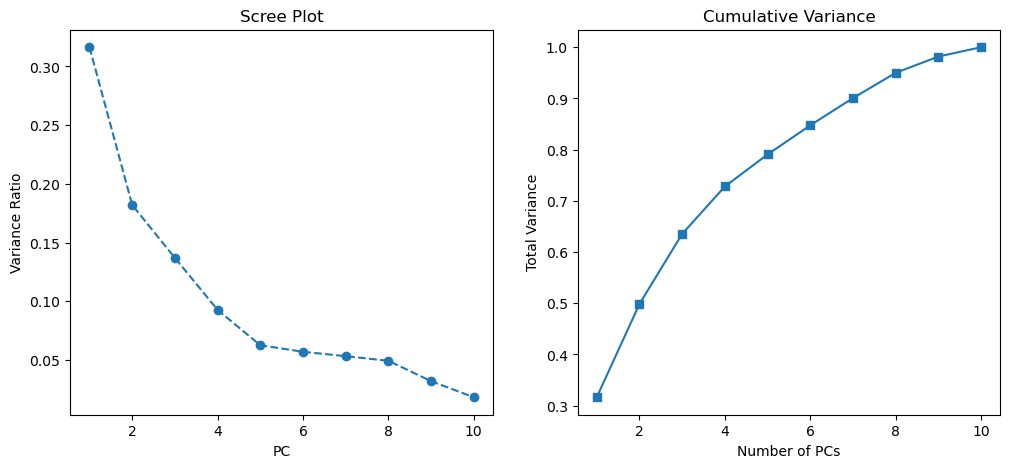

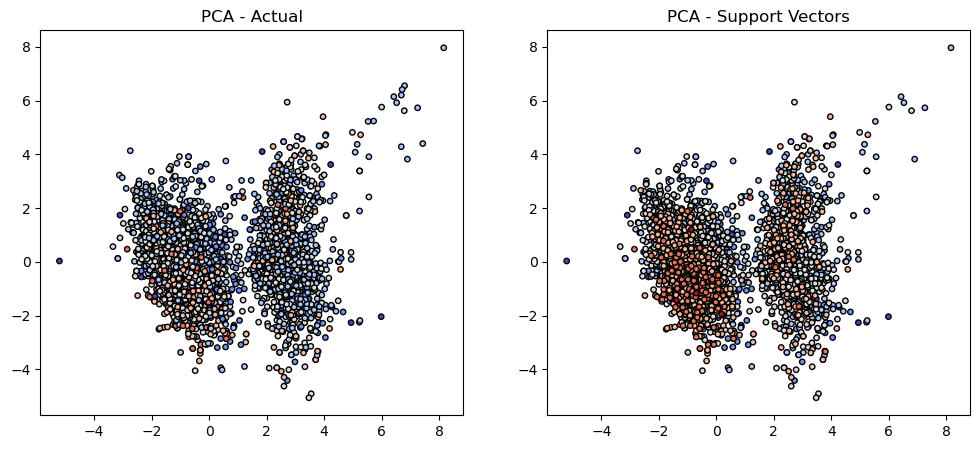

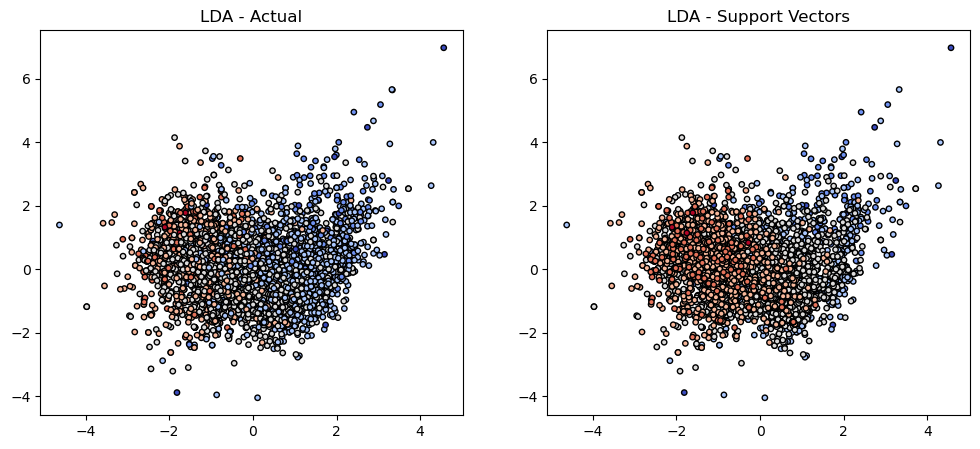

In [20]:
#  Scree Plots
pca_full = PCA().fit(X_train_scaled)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), pca_full.explained_variance_ratio_, 'o--')
plt.title('Scree Plot')
plt.xlabel('PC')
plt.ylabel('Variance Ratio')

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), np.cumsum(pca_full.explained_variance_ratio_), 's-')
plt.title('Cumulative Variance')
plt.xlabel('Number of PCs')
plt.ylabel('Total Variance')
plt.show()

# SVM Support Vector Plots
from sklearn.svm import SVC
# using C=10.0 based on the best results from the table
svm_pca = SVC(C=10.0, kernel='rbf').fit(X_train_pca, y_train)
svm_lda = SVC(C=10.0, kernel='rbf').fit(X_train_lda, y_train)

def plot_sv(X_data, y_data, model, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(X_data[:,0], X_data[:,1], c=y_data, cmap='coolwarm', s=15, edgecolors='k')
    plt.title(f'{title} - Actual')
    
    plt.subplot(1, 2, 2)
    sv = model.support_vectors_
    sv_y = y_data.iloc[model.support_]
    plt.scatter(sv[:,0], sv[:,1], c=sv_y, cmap='coolwarm', s=15, edgecolors='k')
    plt.title(f'{title} - Support Vectors')
    plt.show()

plot_sv(X_train_pca, y_train, svm_pca, "PCA")
plot_sv(X_train_lda, y_train, svm_lda, "LDA")